<font color='blue'> **06 _____** </font>

In [1]:
import numpy as np  ; import matplotlib.pyplot as plt    ; from pathlib import Path             ; import fipy as fp
from fipy import CellVariable, Grid2D,  DiffusionTerm    ; from fipy.tools import numerix       ; from fipy import Gmsh2D, Gmsh3D
import warnings;warnings.filterwarnings("ignore", category=UserWarning); from importlib.metadata import entry_points

# File=Path('E:/15_REPOS/d05_gmsh-4.15.2/examples/boolean/simple.geo')              #  $ python tutorials/python/t2.py     ((((( gmsh-4.15.2 )))))

In [2]:
LX = 20
mesh = Gmsh2D(''' CE = 0.5 ;
Point(2)={0,0,0 ,CE}    ; Point(3)={%(LX)g,0,0 ,CE}  ; Point(4)={%(LX)g,%(LX)g, 0  ,CE}   ; Point(5) = {0,%(LX)g,0 ,CE};
Line(6) = {2, 3}        ; Line(7) = {3, 4}           ; Line(8) = {4, 5}                   ; Line(9) = {5, 2}      ; 
Line Loop(10) = {6, 7, 8, 9};   Plane Surface(11) = {10} ;
''' 
% locals())

In [3]:
LX

20

In [4]:
valueLeft = 0.  ; valueRight = 1.
var = CellVariable(name = "solution variable",mesh = mesh, value = valueLeft)       ; var.constrain(valueLeft, mesh.facesLeft)    ; var.constrain(valueRight, mesh.facesRight)
DiffusionTerm().solve(var)       ; x = mesh.cellCenters[0]      ; analyticalArray = valueLeft + (valueRight - valueLeft) * x / LX

In [5]:
%%capture
def Viewer(vars, title=None, limits={}, **kwlimits):
    viewers = []     ; vars = [var for var in vars if var.mesh.numberOfCells > 0]    ; enpts = sorted(entry_points(group="fipy.viewers"))
    for ep in enpts:
        ViewerClass = ep.load()  ;fig, ax = plt.subplots(figsize=(3, 2))  ;viewer=ViewerClass(vars=vars,title=title,axes=ax,limits=limits,**kwlimits);viewers.append(viewer)
        break
    return viewers[0]
viewer = Viewer(vars=(var, ),datamin=0., datamax=1.)

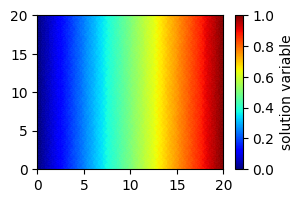

In [6]:
viewer.plot()

In [7]:
var.shape

(3722,)

In [10]:
import gmsh     ; gmsh.write("t2.msh")          # where tf?

1861


<Figure size 640x480 with 0 Axes>

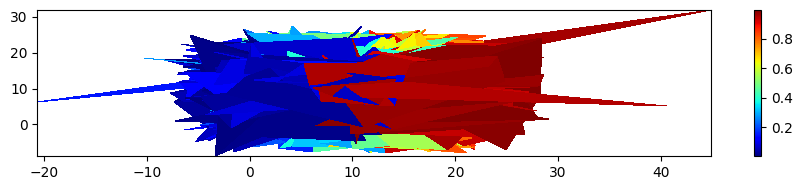

In [11]:
AA = (2, int(len(var.value)/2))                ;xx = mesh.cellCenters[0].value.reshape(AA)                     ;yy = mesh.cellCenters[1].value.reshape(AA)    ; print(int(len(var.value)/2))
fig, (ax1) = plt.subplots(1, 1,figsize=(9, 2)) ;WW = ax1.pcolormesh(xx, yy, var.value.reshape(AA),cmap='jet')  ;cbar = plt.colorbar(WW)  ; plt.tight_layout() ; plt.show(); 

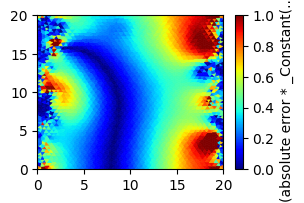

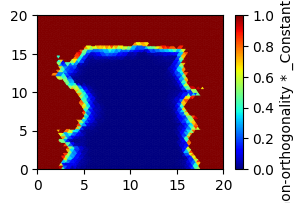

In [12]:
errorVar = abs(var - analyticalArray)   ; errorVar.name = "absolute error"              ; NonOrthoVar = CellVariable(name="non-orthogonality",mesh=mesh,value=mesh._nonOrthogonality)
viewer = Viewer(vars=(errorVar*1000, ),datamin=0., datamax=1.)                          # errorVar.value.max()*1000
viewer = Viewer(vars=(NonOrthoVar*1000, ),datamin=0., datamax=1.)                          # errorVar.value.max()*1000

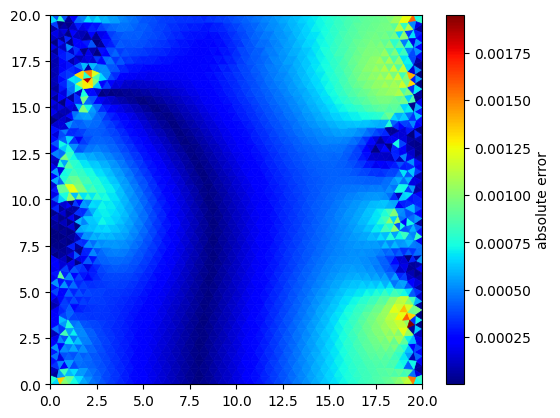

In [13]:
from fipy import Viewer
viewer = Viewer(vars=errorVar)